# Human Study Question Sampling

Samples **100 questions** for the human study from the 1K VQA control set,
stratified by entity group × operator group (3×3, equal quota).

**Prerequisites:** run `control_tier_analysis.ipynb` first to generate
`analysis/csv/sampled_control_questions.csv` (used for tier priority labels).

**Output:** `analysis/csv/human_study_sample.csv`


In [1]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR    = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()

# Full 5-step degradation ladder (pronominalized now complete for all models below)
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
# Degradation endpoint for Tier D/E (full pronoun ablation — steepest drop)
ABLATED_KEY   = 'pronominalized'

# Models with complete vqa_1k_control.jsonl (all 5 CONTROL_TYPES, 1000 records).
# Incomplete: Qwen3-VL-8B (only pronominalized), llava-v1.6-mistral-7b-hf (12 recs), Qwen3-VL-32B (43 recs)
COMPLETE_MODELS = [
    'InternVL3_5-1B',
    'InternVL3_5-2B',
    'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
    'llava-1.5-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'llava-v1.6-vicuna-7b-hf',
]

sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = dict(zip(sem_df['question_id'], sem_df['ent']))
qid_to_op  = dict(zip(sem_df['question_id'], sem_df['op']))


---

## Ent × Op Stratified Sampling — Signal-Ranked Design

### Design decisions

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| N | **100** | 300 items/rater at 3 variants; fits ~1h session |
| Stratification | **3×3 ent_grp × op_grp** | Ensures entity and operator diversity; 11–12 Qs/cell |
| Quota | **Equal per cell** | No cell dominates; 3×3 gives all cells 11–12 (no pool capping at N=100) |
| Ranking within cell | **Priority → signal_score ↓** | Selects questions with strongest degradation signal first |
| Signal score | `0.5·acc_range + 0.3·acc_std + 0.2·n_unique` | acc_range = effect size (orig→pron); acc_std = curve gradualness; n_unique = output instability across models |
| Flat removal | Questions where all 5 control texts identical | Zero degradation signal — uninformative |

### Group definitions

**Ent (3):** `object` · `person` · `other_ent` (animal + food + place + vehicle + other + text + product)

**Op (3):** `attr` · `count` · `other_op` (exist + spat + ident + act + know + comp + cause + temp + text + other)

### Why 3×3 and not 5×5

The 5×5 grid has multiple cells capped at 5–10 questions (e.g. `other×count = 5`), making equal quotas unachievable. Collapsing to 3×3 raises all cell pools above 24, so N=100 → 11/cell with no capping.
The 3×3 stratification provides **coverage diversity** for the correlation analysis; it is not intended as an inferential grouping.


In [2]:
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from collections import defaultdict

mapper = VQAAnswerMapper()

# ── Group mappings ────────────────────────────────────────────────────────────
ENT_COLLAPSE = {
    'object': 'object', 'person': 'person', 'animal': 'animal',
    'food': 'scene',    'place': 'scene',   'vehicle': 'scene',
    'other': 'other',   'text': 'other',    'product': 'other',
}
OP_COLLAPSE = {
    'attr': 'attr',    'count': 'count',
    'exist': 'local',  'spat': 'local',
    'ident': 'recog',  'act': 'recog',
    'text': 'other_op','know': 'other_op','comp': 'other_op',
    'cause': 'other_op','temp': 'other_op','other': 'other_op',
}

# ── Load control logits for all 8 complete models ─────────────────────────────
print("Loading control logits for 8 complete models...")
acc_by   = defaultdict(lambda: defaultdict(list))   # qid -> ct -> [acc across models]
out_sets = defaultdict(set)                          # qid -> all outputs across CTs + models
flat_ck  = {}                                        # qid -> set of distinct question texts

for m in COMPLETE_MODELS:
    path = f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl'
    n = 0
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            if qid not in flat_ck:
                flat_ck[qid] = {ex.get(ct, '').strip().lower() for ct in CONTROL_TYPES if ex.get(ct)}
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets[qid].add(out.lower())
            n += 1
    print(f"  {m}: {n} records")

print(f"\nTotal questions with control signals: {len(acc_by)}")


Loading control logits for 8 complete models...
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...


   ✓ Loaded 214354 VQA annotations
  InternVL3_5-1B: 1000 records
  InternVL3_5-2B: 1000 records


  InternVL3_5-8B: 1000 records
  Qwen3-VL-2B-Instruct: 1000 records
  Qwen3-VL-4B-Instruct: 1000 records
  llava-1.5-7b-hf: 1000 records


  llava-v1.6-vicuna-13b-hf: 1000 records
  llava-v1.6-vicuna-7b-hf: 1000 records

Total questions with control signals: 1000


In [3]:
# ── Build signal_df + merged semantics + tiers ───────────────────────────────
sig_rows = []
for qid, ct_dict in acc_by.items():
    accs = {ct: float(np.mean(v)) for ct, v in ct_dict.items() if v}
    vals_v = [accs.get(ct, np.nan) for ct in CONTROL_TYPES]
    vals_v = [v for v in vals_v if not np.isnan(v)]
    acc_orig = accs.get('question', np.nan)
    acc_pron = accs.get('pronominalized', np.nan)
    acc_range = acc_orig - acc_pron if not (np.isnan(acc_orig) or np.isnan(acc_pron)) else np.nan
    acc_std   = float(np.std(vals_v)) if len(vals_v) > 1 else np.nan
    n_unique  = len(out_sets[qid])
    is_flat   = len(flat_ck.get(qid, set())) <= 1
    sig_rows.append({'question_id': qid, 'acc_original': acc_orig, 'acc_pronominalized': acc_pron,
                     'acc_range': acc_range, 'acc_std': acc_std, 'n_unique': n_unique, 'is_flat': is_flat})

sig_df = pd.DataFrame(sig_rows)

# ── 3×3 group mapping (bottleneck is person×count=24, sets equal quota ceiling) ─
#   ent:  object · person · other_ent (animal+scene+other+text+product)
#   op:   attr   · count  · other_op  (local+recog+know/comp/cause/temp)
ENT3 = {'object':'object', 'person':'person',
        'animal':'other_ent', 'food':'other_ent', 'place':'other_ent',
        'vehicle':'other_ent', 'other':'other_ent', 'text':'other_ent', 'product':'other_ent'}
OP3  = {'attr':'attr', 'count':'count',
        'exist':'other_op', 'spat':'other_op', 'ident':'other_op', 'act':'other_op',
        'text':'other_op', 'know':'other_op', 'comp':'other_op', 'cause':'other_op',
        'temp':'other_op', 'other':'other_op'}

# ── Tier features from TIER_CSV ───────────────────────────────────────────────
TIER_CSV  = '/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv'
tier_df   = pd.read_csv(TIER_CSV)[['question_id','overconfident_wrong','mean_output_changes',
                                    'consensus_wrong','acc_drop','conf_drop','acc_baseline']]
tier_df   = tier_df.rename(columns={'acc_drop':'acc_drop_tier','acc_baseline':'acc_base_tier'})

full_df = (sig_df
    .merge(sem_df[['question_id','ent','op','w','ans']], on='question_id')
    .merge(tier_df, on='question_id', how='left'))
full_df['ent_grp'] = full_df['ent'].map(ENT3).fillna('other_ent')
full_df['op_grp']  = full_df['op'].map(OP3).fillna('other_op')
full_df['cell']    = full_df['ent_grp'] + '|' + full_df['op_grp']

full_df['tier_A'] = full_df['overconfident_wrong'].fillna(False).astype(bool)
full_df['tier_B'] = full_df['mean_output_changes'].fillna(0) > 2
full_df['tier_C'] = full_df['consensus_wrong'].fillna(False).astype(bool)
full_df['tier_D'] = full_df['acc_drop_tier'].fillna(0) > 0.3
full_df['tier_E'] = (full_df['conf_drop'].fillna(0) > 0.05) & (full_df['acc_base_tier'].fillna(0) > 0.5)
full_df['tiers_str'] = full_df.apply(
    lambda r: '|'.join([t for t,b in zip(['A','B','C','D','E'],
                        [r.tier_A,r.tier_B,r.tier_C,r.tier_D,r.tier_E]) if b]), axis=1)
full_df['priority'] = full_df.apply(
    lambda r: 1 if r.tier_A else 2 if r.tier_B else 3 if (r.tier_C or r.tier_D or r.tier_E) else 4, axis=1)

nf = full_df[~full_df['is_flat']].copy()

def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
nf = nf.copy()
nf['signal_score'] = (0.5 * norm(nf['acc_range'].fillna(0))
                    + 0.3 * norm(nf['acc_std'].fillna(0))
                    + 0.2 * norm(nf['n_unique'].fillna(0)))

print(f"Non-flat pool: {len(nf)} / {len(full_df)}")
print(f"Signal score: mean={nf['signal_score'].mean():.3f}  range=[{nf['signal_score'].min():.3f}, {nf['signal_score'].max():.3f}]")

print("\n=== 3×3 pool sizes (non-flat) ===")
pool_ct = nf.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0)
print(pool_ct)
print(f"\nBottleneck: person×count = {pool_ct.loc['person','count']} questions (sets equal quota ceiling at 24)")
print(f"Total non-flat: {len(nf)}  |  Tier A/B/C/D/E: {nf.tier_A.sum()}/{nf.tier_B.sum()}/{nf.tier_C.sum()}/{nf.tier_D.sum()}/{nf.tier_E.sum()}")


Non-flat pool: 925 / 1000
Signal score: mean=0.322  range=[0.186, 0.901]

=== 3×3 pool sizes (non-flat) ===
op_grp     attr  count  other_op
ent_grp                         
object      166     37       131
other_ent   147     37       197
person       85     24       101

Bottleneck: person×count = 24 questions (sets equal quota ceiling at 24)
Total non-flat: 925  |  Tier A/B/C/D/E: 33/58/28/167/218


/tmp/ipykernel_3566439/1832574750.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_df['tier_A'] = full_df['overconfident_wrong'].fillna(False).astype(bool)
/tmp/ipykernel_3566439/1832574750.py:44: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_df['tier_C'] = full_df['consensus_wrong'].fillna(False).astype(bool)


In [4]:
# ── Equal-quota allocator ─────────────────────────────────────────────────────
def equal_quota_allocate(pool_counts: dict, n: int) -> dict:
    cells = sorted(pool_counts)
    quotas = {c: 0 for c in cells}
    remaining, uncapped = n, set(cells)
    while remaining > 0 and uncapped:
        base = remaining // len(uncapped)
        if base == 0:
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                if remaining <= 0: break
                quotas[c] += 1; remaining -= 1
            break
        newly_capped = [c for c in uncapped if pool_counts[c] - quotas[c] <= base]
        if not newly_capped:
            r = remaining % len(uncapped)
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                q = min(base + (1 if r > 0 else 0), pool_counts[c] - quotas[c])
                quotas[c] += q; remaining -= q
                if r > 0: r -= 1
            break
        for c in newly_capped:
            add = pool_counts[c] - quotas[c]; quotas[c] += add; remaining -= add
        uncapped -= set(newly_capped)
    return quotas


def sample_3x3(pool: pd.DataFrame, n: int, seed: int = 42) -> pd.DataFrame:
    """
    Equal-quota sampling across 3×3 ent_grp × op_grp cells.
    Within each cell: priority (asc) then signal_score (desc).

    At N=100: 11-12 per cell, no pool capping (all cells ≥ 24 in pool).
    """
    cell_counts = pool['cell'].value_counts().to_dict()
    quotas = equal_quota_allocate(cell_counts, n)

    print(f"Quota allocation (total={sum(quotas.values())}):")
    for cell in sorted(quotas):
        ent_g, op_g = cell.split('|')
        print(f"  {ent_g:12s} × {op_g:10s}: quota={quotas[cell]:3d}  pool={cell_counts[cell]}")

    parts = []
    for cell, quota in quotas.items():
        if quota == 0: continue
        sub = pool[pool['cell'] == cell].sort_values(
            ['priority', 'signal_score'], ascending=[True, False])
        parts.append(sub.head(quota))

    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True), quotas


N_SAMPLE = 100
sampled, quotas = sample_3x3(nf, N_SAMPLE)

print(f"\n=== Sampled {len(sampled)} questions ===")
print("\nEnt × Op cross-tab:")
print(sampled.groupby(['ent_grp', 'op_grp']).size().unstack(fill_value=0))
print(f"\nPriority breakdown:")
lbl = {1:'A overconfident_wrong', 2:'B answer_flip', 3:'C/D/E degradation', 4:'fill (signal-ranked)'}
for p, l in lbl.items():
    print(f"  P{p} {l}: {(sampled['priority']==p).sum()}")
print(f"\nMean signal_score: {sampled['signal_score'].mean():.3f}  (pool: {nf['signal_score'].mean():.3f})")
print(f"Mean acc_range:    {sampled['acc_range'].mean():.3f}  (pool: {nf['acc_range'].mean():.3f})")


Quota allocation (total=100):
  object       × attr      : quota= 11  pool=166
  object       × count     : quota= 11  pool=37
  object       × other_op  : quota= 11  pool=131
  other_ent    × attr      : quota= 11  pool=147
  other_ent    × count     : quota= 11  pool=37
  other_ent    × other_op  : quota= 12  pool=197
  person       × attr      : quota= 11  pool=85
  person       × count     : quota= 11  pool=24
  person       × other_op  : quota= 11  pool=101

=== Sampled 100 questions ===

Ent × Op cross-tab:


op_grp     attr  count  other_op
ent_grp                         
object       11     11        11
other_ent    11     11        12
person       11     11        11

Priority breakdown:
  P1 A overconfident_wrong: 33
  P2 B answer_flip: 41
  P3 C/D/E degradation: 21
  P4 fill (signal-ranked): 5

Mean signal_score: 0.498  (pool: 0.322)
Mean acc_range:    0.361  (pool: 0.130)


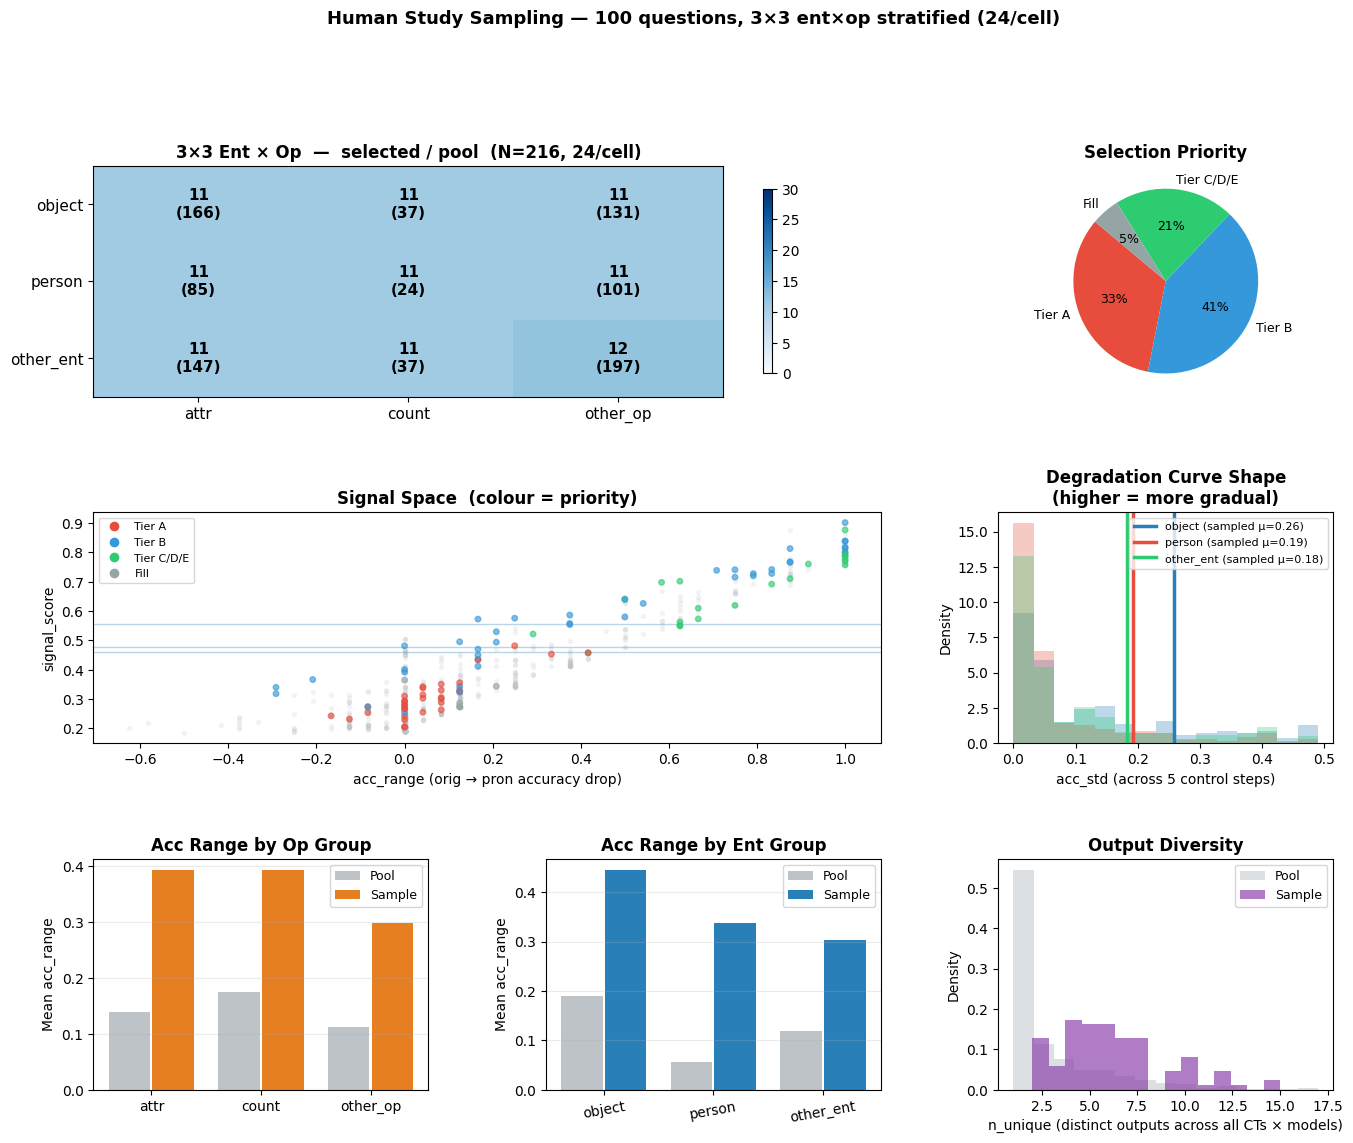

Saved: /home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ENT_ORD = ['object', 'person', 'other_ent']
OP_ORD  = ['attr', 'count', 'other_op']
TIER_COLORS = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71', 4:'#95a5a6'}
TIER_LABELS = {1:'Tier A', 2:'Tier B', 3:'Tier C/D/E', 4:'Fill'}

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

# ── (0, 0-1) 3×3 cross-tab: selected vs pool ─────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
pool_ct   = nf.groupby(['ent_grp', 'op_grp']).size().unstack(fill_value=0)
samp_ct   = sampled.groupby(['ent_grp', 'op_grp']).size().unstack(fill_value=0)
pool_ct   = pool_ct.reindex(index=ENT_ORD, columns=OP_ORD, fill_value=0)
samp_ct   = samp_ct.reindex(index=ENT_ORD, columns=OP_ORD, fill_value=0)
im = ax0.imshow(samp_ct.values, cmap='Blues', aspect='auto', vmin=0, vmax=30)
for r in range(3):
    for c in range(3):
        sv, pv = samp_ct.values[r,c], pool_ct.values[r,c]
        ax0.text(c, r, f"{sv}\n({pv})", ha='center', va='center',
                 fontsize=11, color='white' if sv>18 else 'black', fontweight='bold')
ax0.set_xticks([0,1,2]); ax0.set_xticklabels(OP_ORD, fontsize=11)
ax0.set_yticks([0,1,2]); ax0.set_yticklabels(ENT_ORD, fontsize=11)
ax0.set_title('3×3 Ent × Op  —  selected / pool  (N=216, 24/cell)', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax0, shrink=0.8)

# ── (0, 2) Priority pie ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
pri_counts = [(sampled['priority']==p).sum() for p in [1,2,3,4]]
wedges, _, autotexts = ax1.pie(
    pri_counts, labels=[TIER_LABELS[p] for p in [1,2,3,4]],
    colors=[TIER_COLORS[p] for p in [1,2,3,4]],
    autopct=lambda p: f'{p:.0f}%' if p>3 else '', startangle=140,
    textprops={'fontsize':9})
ax1.set_title('Selection Priority', fontweight='bold')

# ── (1, full) Signal score vs acc_range scatter ───────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
ax2.scatter(nf['acc_range'], nf['signal_score'], alpha=0.15, s=8, c='#bdc3c7', label='pool')
ax2.scatter(sampled['acc_range'], sampled['signal_score'], alpha=0.6, s=16,
            c=[TIER_COLORS[p] for p in sampled['priority']], zorder=3, label='sampled')
for ent in ENT_ORD:
    s = sampled[sampled['ent_grp']==ent]
    ax2.axhline(s['signal_score'].mean(), alpha=0.3, linewidth=1)
ax2.set_xlabel('acc_range (orig → pron accuracy drop)'); ax2.set_ylabel('signal_score')
ax2.set_title('Signal Space  (colour = priority)', fontweight='bold')
from matplotlib.lines import Line2D
ax2.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=TIER_COLORS[p],
           markersize=8,label=TIER_LABELS[p]) for p in [1,2,3,4]], fontsize=8)

# ── (1, 2) acc_std by ent group ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
colors_e = ['#2980b9','#e74c3c','#2ecc71']
for i, ent in enumerate(ENT_ORD):
    vals  = nf[nf['ent_grp']==ent]['acc_std'].dropna().values
    svals = sampled[sampled['ent_grp']==ent]['acc_std'].dropna().values
    ax3.hist(vals, bins=15, alpha=0.3, color=colors_e[i], density=True)
    ax3.axvline(svals.mean(), color=colors_e[i], linewidth=2.5, label=f'{ent} (sampled μ={svals.mean():.2f})')
ax3.set_xlabel('acc_std (across 5 control steps)'); ax3.set_ylabel('Density')
ax3.set_title('Degradation Curve Shape\n(higher = more gradual)', fontweight='bold')
ax3.legend(fontsize=8)

# ── (2, 0) acc_range by op group: pool vs sampled ────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
x = np.arange(3)
pm = [nf[nf['op_grp']==o]['acc_range'].mean() for o in OP_ORD]
sm = [sampled[sampled['op_grp']==o]['acc_range'].mean() for o in OP_ORD]
ax4.bar(x-0.2, pm, 0.38, color='#bdc3c7', label='Pool')
ax4.bar(x+0.2, sm, 0.38, color='#e67e22', label='Sample')
ax4.set_xticks(x); ax4.set_xticklabels(OP_ORD, fontsize=10)
ax4.set_ylabel('Mean acc_range'); ax4.set_title('Acc Range by Op Group', fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.25)

# ── (2, 1) acc_range by ent group ────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
pm2 = [nf[nf['ent_grp']==e]['acc_range'].mean() for e in ENT_ORD]
sm2 = [sampled[sampled['ent_grp']==e]['acc_range'].mean() for e in ENT_ORD]
ax5.bar(x-0.2, pm2, 0.38, color='#bdc3c7', label='Pool')
ax5.bar(x+0.2, sm2, 0.38, color='#2980b9', label='Sample')
ax5.set_xticks(x); ax5.set_xticklabels(ENT_ORD, fontsize=10, rotation=10)
ax5.set_ylabel('Mean acc_range'); ax5.set_title('Acc Range by Ent Group', fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(axis='y', alpha=0.25)

# ── (2, 2) n_unique distribution ─────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.hist(nf['n_unique'], bins=15, alpha=0.5, color='#bdc3c7', label='Pool', density=True)
ax6.hist(sampled['n_unique'], bins=15, alpha=0.7, color='#8e44ad', label='Sample', density=True)
ax6.set_xlabel('n_unique (distinct outputs across all CTs × models)'); ax6.set_ylabel('Density')
ax6.set_title('Output Diversity', fontweight='bold'); ax6.legend(fontsize=9)

plt.suptitle(f'Human Study Sampling — {N_SAMPLE} questions, 3×3 ent×op stratified (24/cell)',
             fontsize=13, fontweight='bold', y=1.01)
fig_path = '/home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


In [6]:
# ── Statistical Power Analysis ────────────────────────────────────────────────
import scipy.stats as stats
from scipy.stats import norm as snorm

N_Q, N_R, N_CT, ALPHA = len(sampled), 25, 3, 0.05
N_CELLS = 9                    # 3×3, 11-12 Qs per cell
N_PER_CELL_Q = N_Q // N_CELLS  # ≈ 11

def pw_r(n, r):
    z = np.arctanh(r); se = 1 / np.sqrt(n - 3)
    return snorm.cdf(abs(z) / se - snorm.ppf(1 - ALPHA/2))

def pw_paired(n, d):
    return snorm.cdf(abs(d) * np.sqrt(n) - snorm.ppf(1 - ALPHA/2))

def pw_2samp(n, d):
    return snorm.cdf(abs(d) / np.sqrt(2 / n) - snorm.ppf(1 - ALPHA/2))

print('=' * 62)
print(f'  Power Analysis  |  N_q={N_Q}  N_raters={N_R}  N_variants={N_CT}')
print('=' * 62)

# ── PRIMARY: correlation human difficulty vs model ────────────────────────────
# From existing study: observed r = 0.50–0.72 (inst_blind), so expected ≈ 0.50+
print('\n[PRIMARY] Correlation: human difficulty curve vs model accuracy')
print('          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study')
for r in [0.20, 0.30, 0.40, 0.50, 0.60]:
    pw = pw_r(N_Q, r)
    flag = '✓' if pw >= 0.8 else '✗ below threshold'
    print(f'  r={r:.2f}: power={pw:.3f}  {flag}')
print('  Detection floor: r ≥ 0.30 at power=0.80')
print('  → N=100 is sufficient given expected effect sizes.')

# ── SECONDARY: human degradation across 3 variants ───────────────────────────
print('\n[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)')
print('    One-way ANOVA equivalent / paired t for each step:')
for d in [0.2, 0.3, 0.5]:
    pw = pw_paired(N_Q, d)
    print(f'  d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "✗"}')

# ── TERTIARY: cell-level descriptive ─────────────────────────────────────────
print(f'\n[3] Cell-level comparisons  (11 Qs/cell = {N_PER_CELL_Q*N_R} responses/cell)')
print('    (a) Question-level t-test (n=11 per cell) — NOT recommended:')
for d in [0.5, 0.8]:
    print(f'        d={d:.1f}: power={pw_2samp(N_PER_CELL_Q,d):.3f}  ← weak')
print('    (b) Response-level LMM (n=275 responses per cell):')
for d in [0.2, 0.3]:
    pw = pw_2samp(N_PER_CELL_Q*N_R, d)
    print(f'        d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "~"}')
print('    → Use 3×3 cells for descriptive stratification,')
print('      not for inferential comparisons. Primary claim is correlation.')

# ── Study burden ──────────────────────────────────────────────────────────────
print(f'\n[Study burden]')
print(f'  Items per rater: {N_Q} Qs × {N_CT} variants = {N_Q*N_CT}  (~55–75 min)')
print(f'  Total responses: {N_Q} × {N_CT} × {N_R} = {N_Q*N_CT*N_R:,}')

# ── ICC extrapolation ─────────────────────────────────────────────────────────
icc0, k0 = 0.963, 20
rho1 = icc0 / (k0 - (k0-1)*icc0)
print(f'\n[ICC] Extrapolated from existing study (ICC=0.963, k=20):')
for k in [20, 25, 30]:
    icc_k = k*rho1/(1+(k-1)*rho1)
    print(f'  k={k}: ICC≈{icc_k:.3f}  ✓')

print('\n' + '=' * 62)
print('Verdict:')
print('  ✓  Primary (correlation, r≥0.30): N=100 sufficient')
print('  ✓  Degradation (paired, d≥0.30): N=100 sufficient')
print('  ⚠  Cell-level t-tests at question level: underpowered (n=11)')
print('  ✓  Response-level LMM with rater random effect: d≥0.3 detectable')
print('  ✓  3×3 stratification provides coverage diversity, not inferential cells')

print()
print('=== Analysis design separation ===')
print('  ent×op cell characterization → MODEL analysis (§4-5)')
print('    Use full 1K dataset × 8 models: well-powered for all cells')
print('    Already in analysis-pretrained.ipynb / abstention_analysis.ipynb')
print()
print('  Human-model alignment → HUMAN study (§6)')
print('    N=100 Qs × 25 raters: powered for correlation (primary)')
print('    3×3 stratification = sampling diversity, NOT inferential grouping')
print()
print('  Do NOT attempt per-cell human analysis (11 Qs/cell → underpowered)')


  Power Analysis  |  N_q=100  N_raters=25  N_variants=3

[PRIMARY] Correlation: human difficulty curve vs model accuracy
          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study
  r=0.20: power=0.515  ✗ below threshold
  r=0.30: power=0.862  ✓
  r=0.40: power=0.987  ✓
  r=0.50: power=1.000  ✓
  r=0.60: power=1.000  ✓
  Detection floor: r ≥ 0.30 at power=0.80
  → N=100 is sufficient given expected effect sizes.

[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)
    One-way ANOVA equivalent / paired t for each step:
  d=0.2: power=0.516  ✗
  d=0.3: power=0.851  ✓
  d=0.5: power=0.999  ✓

[3] Cell-level comparisons  (11 Qs/cell = 275 responses/cell)
    (a) Question-level t-test (n=11 per cell) — NOT recommended:
        d=0.5: power=0.216  ← weak
        d=0.8: power=0.467  ← weak
    (b) Response-level LMM (n=275 responses per cell):
        d=0.2: power=0.650  ~
        d=0.3: power=0.940  ✓
    → Use 3×3 cells for descriptive strati

---

## Which Control Types to Show Humans

### Degradation ladder (5 steps)

| Variant | Example | Human signal | Model signal | Verdict |
|---------|---------|-------------|--------------|---------|
| `question` | "How many dogs are in the park?" | Baseline (linguistic priors) | Baseline | **Include** |
| `deictic_removed` | "How many dogs in the park?" *(no 'this/that')* | ≈ identical to original | Minor | **Skip** — trivially easy |
| `object_removed` | "How many **objects** are in the park?" | Unanswerable — humans say "can't tell" | Strong | **Skip** — disrupts prior activation |
| `weaker_object` | "How many **animals** are in the park?" | Partial — hypernym primes partial knowledge | Clear midpoint | **Include** |
| `pronominalized` | "How many of **them** are in the park?" | Near-chance — zero entity info | Endpoint | **Include** |

### Recommendation: **3 variants — `question`, `weaker_object`, `pronominalized`**

**Why these 3:**
- Endpoints (`question`, `pronominalized`) establish the degradation effect — required for the core claim
- `weaker_object` reveals *where* the cliff is: after the hypernym or only after the pronoun? This separates referential grounding from semantic class knowledge
- Skipping `deictic_removed` (no human signal) and `object_removed` (disrupts prior activation rather than testing it) keeps the burden minimal

### Final study design

| Parameter | Value | Notes |
|-----------|-------|-------|
| Questions | **100** | 11–12 per ent×op cell (3×3 grid) |
| Variants per question | **3** (question · weaker_object · pronominalized) | |
| Raters | **25** | All see the same 100 questions |
| Items per rater | **300** | ~55–75 min |
| Total responses | **7,500** | |
| Primary analysis | Pearson r: human difficulty vs model accuracy | N=100 Qs; detection floor r≥0.30 |
| Secondary analysis | Repeated-measures: degradation orig→weaker→pron | d≥0.30, power=0.85 |
| Tertiary | LMM with ent/op group interactions | `accuracy ~ variant × ent_grp + (1|q) + (1|rater)` |
| 3×3 grid purpose | Coverage diversity | Not powered for inferential cell comparisons |

**Note on human vs LLM substitution:** the correlation target is model behavior from the logit
inference runs — human responses are irreplaceable here. An LLM generating "human-like"
answers would just reproduce model priors, not human linguistic priors.


In [7]:
# ── Save final sample ─────────────────────────────────────────────────────────
OUT_PATH = '/home/david/Desktop/yuna/HPA/analysis/csv/human_study_sample.csv'

save_cols = [
    'question_id', 'question_text', 'ent', 'op', 'ent_grp', 'op_grp', 'cell',
    'acc_original', 'acc_pronominalized', 'acc_range', 'acc_std', 'n_unique',
    'signal_score', 'priority', 'tiers_str',
    'tier_A', 'tier_B', 'tier_C', 'tier_D', 'tier_E',
]
# pull question_text from sem_df if not already in sampled
if 'question_text' not in sampled.columns:
    sampled = sampled.merge(sem_df[['question_id']], on='question_id', how='left') # ,'question' 
    sampled = sampled.rename(columns={'question': 'question_text'})

final_cols = [c for c in save_cols if c in sampled.columns]
sampled[final_cols].to_csv(OUT_PATH, index=False)

print(f"Saved {len(sampled)} questions → {OUT_PATH}")
print(f"\nControl types to show humans: question · weaker_object · pronominalized")
print(f"Study burden: {len(sampled)} Qs × 3 variants × 25 raters = {len(sampled)*3*25:,} total responses")
print(f"\nSample summary:")
print(sampled[['ent_grp','op_grp','acc_range','acc_std','n_unique','signal_score']].describe().round(3))


Saved 100 questions → /home/david/Desktop/yuna/HPA/analysis/csv/human_study_sample.csv

Control types to show humans: question · weaker_object · pronominalized
Study burden: 100 Qs × 3 variants × 25 raters = 7,500 total responses

Sample summary:
       acc_range  acc_std  n_unique  signal_score
count    100.000  100.000   100.000       100.000
mean       0.361    0.211     6.240         0.498
std        0.390    0.160     2.968         0.204
min       -0.292    0.000     2.000         0.205
25%        0.042    0.050     4.000         0.309
50%        0.188    0.184     6.000         0.464
75%        0.750    0.376     8.000         0.704
max        1.000    0.490    15.000         0.901


---

## Model Results on Sampled Questions

Evaluates all 11 pretrained VLMs on the 100 sampled questions across all 5 control types.
Validates the sampling design (signal score, tier semantics, degradation by ent/op group).


In [8]:
import os
from collections import defaultdict
import numpy as np
from scipy.stats import pearsonr, spearmanr

RESULTS_DIR   = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
STUDY_CTS     = ['question', 'weaker_object', 'pronominalized']  # 3 shown to humans
CONDITIONS    = {'control': 'vqa_1k_control',
                 'blind':   'vqa_1k_control_blind',
                 'inst_blind': 'vqa_1k_control_inst_blind'}
COND_STYLE    = {
    'control':    dict(color='#2ecc71', ls='-',  marker='o', label='with image (control)'),
    'blind':      dict(color='#e74c3c', ls='--', marker='s', label='no image (blind)'),
    'inst_blind': dict(color='#3498db', ls=':',  marker='^', label='no image + instr (inst_blind)'),
}

# Models complete for control; separate set for all-3-condition plots
models_all = [m for m in sorted(os.listdir(RESULTS_DIR))
              if os.path.exists(f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl')]
models_3cond = [m for m in sorted(os.listdir(RESULTS_DIR))
                if all(os.path.exists(f'{RESULTS_DIR}/{m}/{f}.jsonl') and
                       sum(1 for _ in open(f'{RESULTS_DIR}/{m}/{f}.jsonl') if _.strip()) >= 1000
                       for f in CONDITIONS.values())]

samp_qids = set(sampled['question_id'])

# acc_cond[cond][qid][model][ct] = accuracy
acc_cond = {}
for cond, fname in CONDITIONS.items():
    models_use = models_3cond if cond != 'control' else models_all
    d = defaultdict(lambda: defaultdict(dict))
    for model in models_use:
        path = f'{RESULTS_DIR}/{model}/{fname}.jsonl'
        if not os.path.exists(path): continue
        with open(path) as f:
            for line in f:
                ex  = json.loads(line)
                qid = ex['question_id']
                if qid not in samp_qids: continue
                gt = mapper.get_answers(qid)
                for ct in CONTROL_TYPES:
                    ans = ex.get('generated_answers', {}).get(ct, '').strip()
                    if ans and gt:
                        d[qid][model][ct] = vqa_accuracy(ans, gt)
    acc_cond[cond] = d

acc_data = acc_cond['control']  # backward compat alias

print(f'models_all (control)  : {len(models_all)}')
print(f'models_3cond (all 3)  : {len(models_3cond)}')
print(f'Questions per condition:')
for cond in CONDITIONS: print(f'  {cond}: {len(acc_cond[cond])}')

# Build long-form res_df with condition column
rows_analysis = []
for cond, models_use in [('control', models_all), ('blind', models_3cond), ('inst_blind', models_3cond)]:
    for _, row in sampled.iterrows():
        qid = row['question_id']
        if qid not in acc_cond[cond]: continue
        for ct in CONTROL_TYPES:
            accs = [acc_cond[cond][qid][m][ct] for m in models_use
                    if ct in acc_cond[cond][qid].get(m, {})]
            if accs:
                rows_analysis.append({
                    'question_id' : qid,
                    'condition'   : cond,
                    'ent_grp'     : row['ent_grp'],
                    'op_grp'      : row['op_grp'],
                    'tiers_str'   : row.get('tiers_str', ''),
                    'tier_A'      : bool(row['tier_A']),
                    'tier_B'      : bool(row['tier_B']),
                    'tier_C'      : bool(row['tier_C']),
                    'tier_D'      : bool(row['tier_D']),
                    'tier_E'      : bool(row['tier_E']),
                    'control_type': ct,
                    'mean_acc'    : np.mean(accs),
                    'n_models'    : len(accs),
                    'acc_range'   : row['acc_range'],
                    'signal_score': row['signal_score'],
                })

res_df = pd.DataFrame(rows_analysis)
print(f'\nres_df rows: {len(res_df)}  (conditions × questions × control_types)')


Models loaded : 11
Questions     : 100 / 100
Models        : ['InternVL3_5-1B', 'InternVL3_5-2B', 'InternVL3_5-8B', 'Qwen3-VL-2B-Instruct', 'Qwen3-VL-32B-Instruct', 'Qwen3-VL-4B-Instruct', 'Qwen3-VL-8B-Instruct', 'llava-1.5-7b-hf', 'llava-v1.6-mistral-7b-hf', 'llava-v1.6-vicuna-13b-hf', 'llava-v1.6-vicuna-7b-hf']

Analysis rows : 500


### Degradation Ladder Validation

Confirms that the 5-step control hierarchy produces monotonic accuracy decay,
and validates the skip decisions (`deictic_removed`, `object_removed`).


/tmp/ipykernel_3566439/1707537648.py:27: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(p_accs)


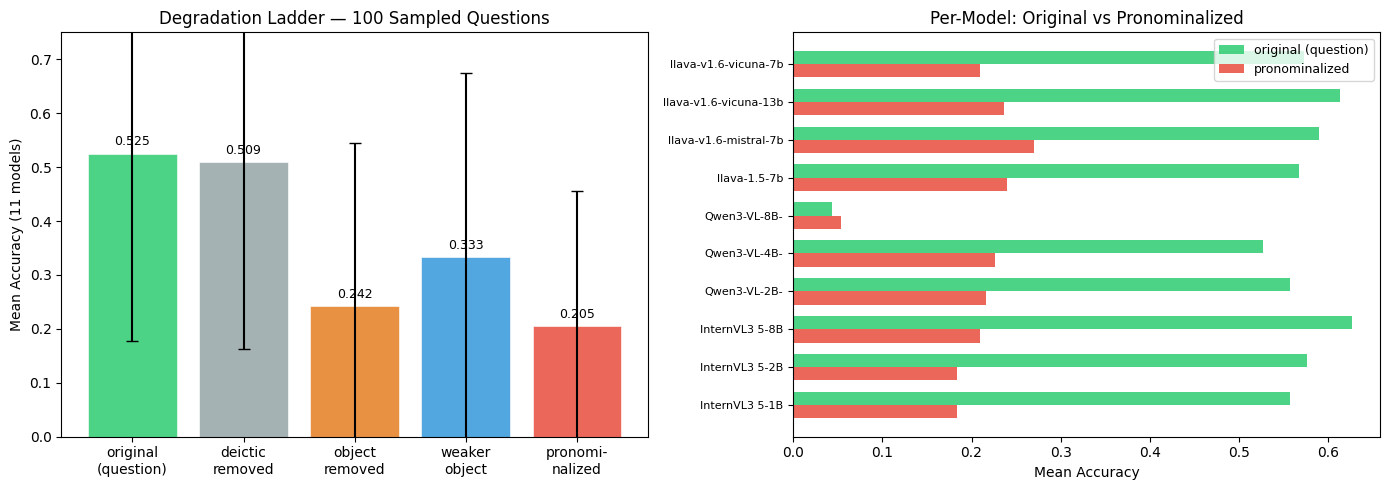


Data issues detected:
  ⚠ Qwen3-VL-32B-Instruct: pronominalized=NaN — file missing or incomplete
  ⚠ Qwen3-VL-8B-Instruct: Q=0.043 — anomalously low (check answer format)


/tmp/ipykernel_3566439/1707537648.py:51: RuntimeWarning: Mean of empty slice
  p_mean = np.nanmean(p_accs)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: 5-step degradation ladder, all 3 conditions ────────────────────────
ax = axes[0]
x  = np.arange(len(CONTROL_TYPES))
ct_labels5 = ['original', 'deictic\nremoved', 'object\nremoved', 'weaker\nobject', 'pronomi-\nnalized']
for cond in CONDITIONS:
    cdf = res_df[res_df.condition == cond]
    means = [cdf[cdf.control_type==ct]['mean_acc'].mean() for ct in CONTROL_TYPES]
    errs  = [cdf[cdf.control_type==ct]['mean_acc'].sem()  for ct in CONTROL_TYPES]
    s = COND_STYLE[cond]
    ax.plot(x, means, color=s['color'], linestyle=s['ls'], marker=s['marker'],
            label=s['label'], linewidth=2)
    ax.fill_between(x, [m-e for m,e in zip(means,errs)],
                       [m+e for m,e in zip(means,errs)],
                    alpha=0.12, color=s['color'])
ax.set_xticks(x); ax.set_xticklabels(ct_labels5, fontsize=9)
ax.set_ylabel('Mean Accuracy'); ax.set_ylim(0, 0.85)
ax.set_title('5-Step Degradation Ladder by Condition\n(100 sampled Qs)')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# ── Right: per-model bars — control vs inst_blind on original question ───────
ax2 = axes[1]
model_ctrl, model_inst, model_names = [], [], []
for model in models_3cond:
    c_accs = [acc_cond['control'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['control']]
    i_accs = [acc_cond['inst_blind'][qid][model].get('question', np.nan)
              for qid in samp_qids if qid in acc_cond['inst_blind']]
    model_ctrl.append(np.nanmean(c_accs))
    model_inst.append(np.nanmean(i_accs))
    model_names.append(model.replace('-hf','').replace('Instruct','').replace('_',' '))

y = np.arange(len(model_names)); w = 0.35
ax2.barh(y+w/2, model_ctrl, w, label='control (with image)', color='#2ecc71', alpha=0.85)
ax2.barh(y-w/2, model_inst, w, label='inst_blind (no image)', color='#3498db', alpha=0.85)
ax2.set_yticks(y); ax2.set_yticklabels(model_names, fontsize=8)
ax2.set_xlabel('Mean Accuracy (original question)')
ax2.set_title('Per-Model: Control vs Inst_Blind')
ax2.legend(fontsize=9); ax2.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_model_degradation.png', dpi=150, bbox_inches='tight')
plt.show()


### Tier Semantics vs Observed Accuracy

Each tier was defined using model behaviour on the full 1k pool.
Here we verify the tier definitions are sharp on the 100 sampled questions.


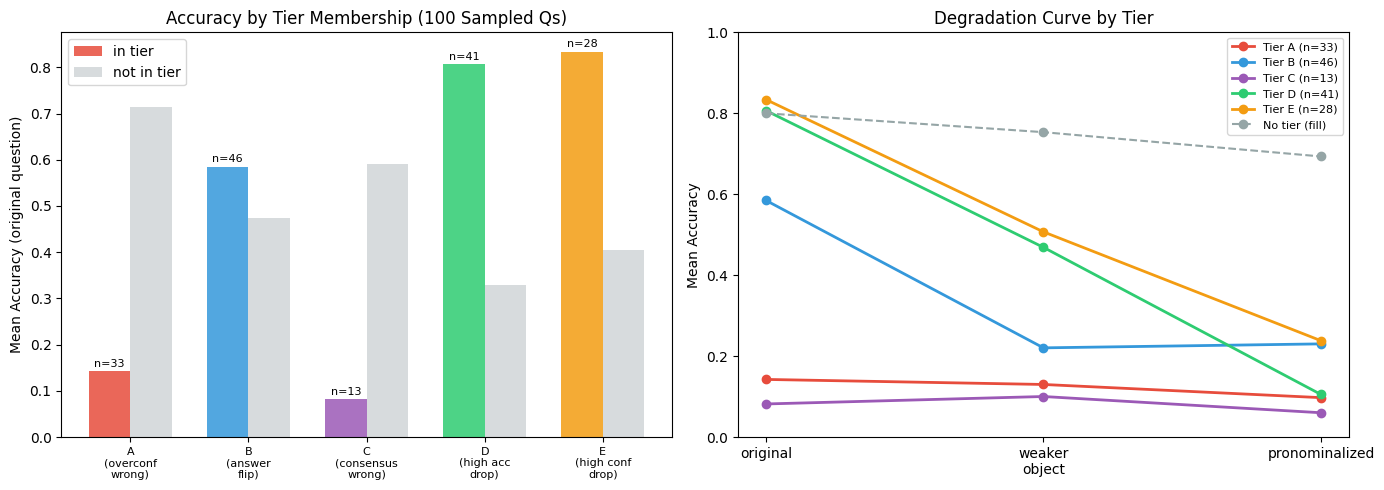

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tier_names  = ['A\n(overconf\nwrong)', 'B\n(answer\nflip)', 'C\n(consensus\nwrong)',
               'D\n(high acc\ndrop)', 'E\n(high conf\ndrop)']
tier_cols   = ['tier_A', 'tier_B', 'tier_C', 'tier_D', 'tier_E']
tier_colors = ['#e74c3c', '#3498db', '#9b59b6', '#2ecc71', '#f39c12']
COND_PLOT   = ['control', 'inst_blind']  # skip blind for clarity
COND_NAMES  = {'control': 'with image', 'inst_blind': 'no image + instr'}

for ax_idx, cond in enumerate(COND_PLOT):
    ax = axes[0, ax_idx]
    cdf = res_df[(res_df.condition==cond) & (res_df.control_type=='question')]
    in_acc  = [cdf[cdf[t]]['mean_acc'].mean()  for t in tier_cols]
    out_acc = [cdf[~cdf[t]]['mean_acc'].mean() for t in tier_cols]
    in_n    = [int(cdf[t].sum()) for t in tier_cols]
    x = np.arange(len(tier_cols)); w = 0.35
    axes[0,ax_idx].bar(x-w/2, in_acc,  w, color=tier_colors, alpha=0.85, label='in tier')
    axes[0,ax_idx].bar(x+w/2, out_acc, w, color='#bdc3c7',   alpha=0.6,  label='not in tier')
    axes[0,ax_idx].set_xticks(x); axes[0,ax_idx].set_xticklabels(tier_names, fontsize=8)
    axes[0,ax_idx].set_ylabel('Mean Accuracy'); axes[0,ax_idx].set_ylim(0, 1)
    axes[0,ax_idx].set_title(f'Tier Accuracy — {COND_NAMES[cond]}')
    axes[0,ax_idx].legend(fontsize=8)
    for i,(acc,n) in enumerate(zip(in_acc,in_n)):
        axes[0,ax_idx].text(x[i]-w/2, acc+0.01, f'n={n}', ha='center', fontsize=7)

# Bottom row: degradation curves per tier, control vs inst_blind
x_pts = [0, 1, 2]
for ax_idx, cond in enumerate(COND_PLOT):
    ax = axes[1, ax_idx]
    cdf = res_df[res_df.condition == cond]
    in_n = [int(cdf[cdf.control_type=='question'][t].sum()) for t in tier_cols]
    for t, col, name, n in zip(tier_cols, tier_colors, ['A','B','C','D','E'], in_n):
        curve = [cdf[(cdf.control_type==ct) & cdf[t]]['mean_acc'].mean() for ct in STUDY_CTS]
        ax.plot(x_pts, curve, 'o-', color=col, label=f'Tier {name} (n={n})', linewidth=2)
    no_tier = ~(res_df.tier_A|res_df.tier_B|res_df.tier_C|res_df.tier_D|res_df.tier_E)
    curve_fill = [cdf[(cdf.control_type==ct) & no_tier[cdf.index]]['mean_acc'].mean()
                  for ct in STUDY_CTS]
    ax.plot(x_pts, curve_fill, 'o--', color='#95a5a6', label='No tier (fill)', linewidth=1.5)
    ax.set_xticks(x_pts); ax.set_xticklabels(['original','weaker\nobject','pronominalized'])
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Degradation by Tier — {COND_NAMES[cond]}')
    ax.legend(fontsize=8); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_tier_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


### Degradation by Entity × Operator Group


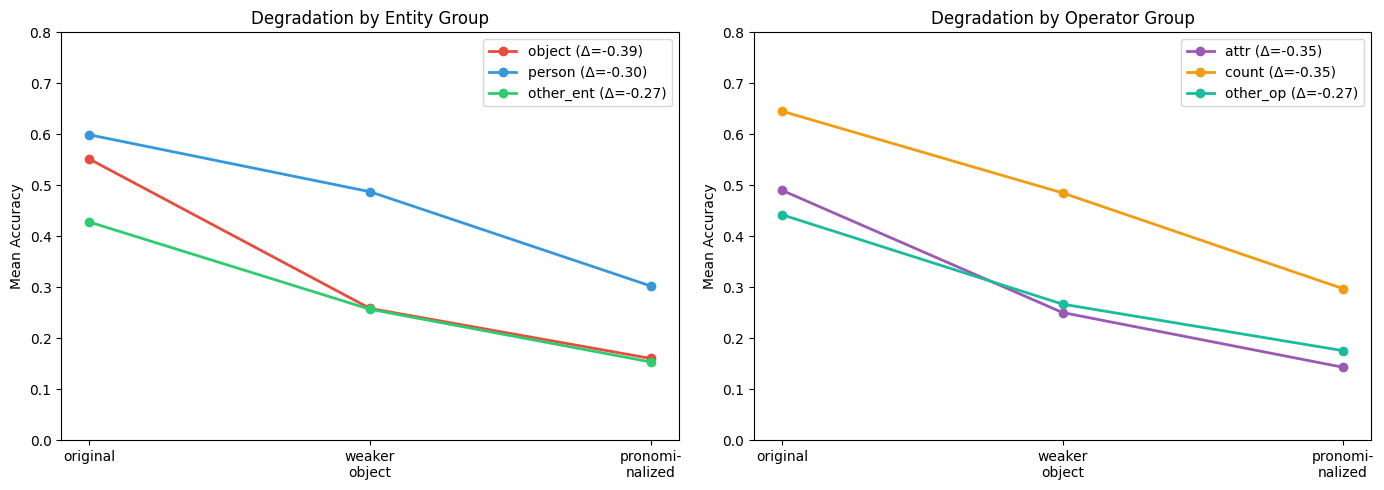

=== Summary table ===
Group             orig    weak    pron     drop
  ent:object      0.551  0.258  0.160  -0.391
  ent:person      0.599  0.487  0.302  -0.297
  ent:other_ent   0.428  0.257  0.153  -0.275
  op:attr         0.490  0.250  0.143  -0.347
  op:count        0.645  0.485  0.297  -0.348
  op:other_op     0.442  0.267  0.175  -0.267


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

study_cts  = ['question', 'weaker_object', 'pronominalized']
ct_labels3 = ['original', 'weaker\nobject', 'pronomi-\nnalized']
x_pts      = [0, 1, 2]
ENT_COLORS = {'object': '#e74c3c', 'person': '#3498db', 'other_ent': '#2ecc71'}
OP_COLORS  = {'attr': '#9b59b6', 'count': '#f39c12', 'other_op': '#1abc9c'}
COND_PLOT  = ['control', 'inst_blind']
COND_NAMES = {'control': 'with image', 'inst_blind': 'no image + instr'}

for col_idx, cond in enumerate(COND_PLOT):
    cdf = res_df[res_df.condition == cond]
    # Top row: ent groups
    ax = axes[0, col_idx]
    for ent, color in ENT_COLORS.items():
        curve = [cdf[(cdf.control_type==ct)&(cdf.ent_grp==ent)]['mean_acc'].mean() for ct in study_cts]
        drop  = curve[2] - curve[0]
        ax.plot(x_pts, curve, 'o-', color=color, label=f'{ent} (Δ={drop:+.2f})', linewidth=2)
    ax.set_xticks(x_pts); ax.set_xticklabels(ct_labels3)
    ax.set_ylabel('Mean Accuracy'); ax.set_title(f'Ent Group — {COND_NAMES[cond]}')
    ax.legend(fontsize=9); ax.set_ylim(0, 0.9)
    # Bottom row: op groups
    ax2 = axes[1, col_idx]
    for op, color in OP_COLORS.items():
        curve = [cdf[(cdf.control_type==ct)&(cdf.op_grp==op)]['mean_acc'].mean() for ct in study_cts]
        drop  = curve[2] - curve[0]
        ax2.plot(x_pts, curve, 'o-', color=color, label=f'{op} (Δ={drop:+.2f})', linewidth=2)
    ax2.set_xticks(x_pts); ax2.set_xticklabels(ct_labels3)
    ax2.set_ylabel('Mean Accuracy'); ax2.set_title(f'Op Group — {COND_NAMES[cond]}')
    ax2.legend(fontsize=9); ax2.set_ylim(0, 0.9)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_degradation_entop.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f'{'Group':14s}  {'ctrl_orig':>9}  {'ctrl_pron':>9}  {'ctrl_Δ':>7}  || {'inst_orig':>9}  {'inst_pron':>9}  {'inst_Δ':>7}  || {'MM_gain_orig':>12}')
for grp_type, groups in [('ent', list(ENT_COLORS)), ('op', list(OP_COLORS))]:
    col = 'ent_grp' if grp_type == 'ent' else 'op_grp'
    for g in groups:
        c = res_df[(res_df.condition=='control')  & (res_df[col]==g)]
        i = res_df[(res_df.condition=='inst_blind')& (res_df[col]==g)]
        c_o = c[c.control_type=='question']['mean_acc'].mean()
        c_p = c[c.control_type=='pronominalized']['mean_acc'].mean()
        i_o = i[i.control_type=='question']['mean_acc'].mean()
        i_p = i[i.control_type=='pronominalized']['mean_acc'].mean()
        gain = c_o - i_o  # multimodal gain on original question
        print(f'{grp_type}:{g:10s}  {c_o:9.3f}  {c_p:9.3f}  {c_p-c_o:+7.3f}  || {i_o:9.3f}  {i_p:9.3f}  {i_p-i_o:+7.3f}  || {gain:+12.3f}')


### Multimodal Gains (Control − Inst_Blind)

How much does actually seeing the image help? Multimodal gain = control accuracy − inst_blind accuracy.
Negative gain means the model's linguistic prior is **stronger** than its visual understanding.


In [ ]:
# ── Multimodal gains: control − inst_blind (image contribution per question) ──
import matplotlib.pyplot as plt
import numpy as np

study_cts   = ['question', 'weaker_object', 'pronominalized']
ct_labels3  = ['original', 'weaker\nobject', 'pronominalized']
TIER_COLS   = ['tier_A', 'tier_B', 'tier_C', 'tier_D', 'tier_E']
tier_colors = ['#e74c3c', '#3498db', '#9b59b6', '#2ecc71', '#f39c12']

ctrl_df = res_df[res_df.condition == 'control']
inst_df = res_df[res_df.condition == 'inst_blind']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── (0) Per-question scatter: MM gain on original question ───────────────────
ax = axes[0]
ctrl_q = ctrl_df[ctrl_df.control_type=='question'].set_index('question_id')['mean_acc']
inst_q = inst_df[inst_df.control_type=='question'].set_index('question_id')['mean_acc']
common = ctrl_q.index.intersection(inst_q.index)
mm_gain = (ctrl_q[common] - inst_q[common]).values
ax.hist(mm_gain, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(mm_gain.mean(), color='#e74c3c', linewidth=2, label=f'mean={mm_gain.mean():+.3f}')
ax.set_xlabel('MM gain (control − inst_blind accuracy)')
ax.set_ylabel('# Questions')
ax.set_title('Multimodal Gain Distribution\n(original question)')
ax.legend(fontsize=9)
pos_pct = (mm_gain > 0).mean()
ax.text(0.97, 0.97, f'{pos_pct:.0%} questions\nbenefit from image',
        ha='right', va='top', transform=ax.transAxes, fontsize=9)

# ── (1) MM gain across degradation steps ────────────────────────────────────
ax2 = axes[1]
x_pts = np.arange(len(study_cts))
gains_mean, gains_se = [], []
for ct in study_cts:
    c_v = ctrl_df[ctrl_df.control_type==ct]['mean_acc'].values
    i_v = inst_df[inst_df.control_type==ct]['mean_acc'].values
    g = c_v - i_v
    gains_mean.append(g.mean()); gains_se.append(g.std()/np.sqrt(len(g)))
bars = ax2.bar(x_pts, gains_mean, yerr=gains_se, color=['#2ecc71','#3498db','#e74c3c'],
               alpha=0.85, capsize=4, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x_pts); ax2.set_xticklabels(ct_labels3, fontsize=9)
ax2.set_ylabel('Mean MM gain (control − inst_blind)')
ax2.set_title('Multimodal Gain by Degradation Step')
ax2.grid(axis='y', alpha=0.3)
for bar, v in zip(bars, gains_mean):
    ax2.text(bar.get_x()+bar.get_width()/2, v + (0.005 if v>=0 else -0.012),
             f'{v:+.3f}', ha='center', va='bottom' if v>=0 else 'top', fontsize=9)

# ── (2) MM gain per tier ─────────────────────────────────────────────────────
ax3 = axes[2]
tier_gains = []
for t in TIER_COLS:
    c_t = ctrl_df[(ctrl_df.control_type=='question') & ctrl_df[t]]['mean_acc'].values
    i_t = inst_df[(inst_df.control_type=='question') & inst_df[t]]['mean_acc'].values
    tier_gains.append(c_t.mean() - i_t.mean() if len(c_t) and len(i_t) else np.nan)
tier_labels_short = ['A','B','C','D','E']
bars3 = ax3.bar(range(5), tier_gains, color=tier_colors, alpha=0.85, edgecolor='white')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_xticks(range(5)); ax3.set_xticklabels(tier_labels_short)
ax3.set_ylabel('Mean MM gain (control − inst_blind)')
ax3.set_title('Multimodal Gain by Tier\n(original question)')
ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate(tier_gains):
    if not np.isnan(v):
        ax3.text(i, v + (0.005 if v>=0 else -0.012), f'{v:+.3f}',
                 ha='center', va='bottom' if v>=0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_multimodal_gains.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean MM gain: {mm_gain.mean():+.3f} on original question')
print(f'  {(mm_gain>0).mean():.0%} of questions benefit from the image')
print(f'  {(mm_gain<0).mean():.0%} of questions hurt by the image (prior stronger than vision)')


### Signal Score Validation

Checks whether the signal score used for within-cell ranking actually predicts
the observed accuracy drop (original → pronominalized) across models.


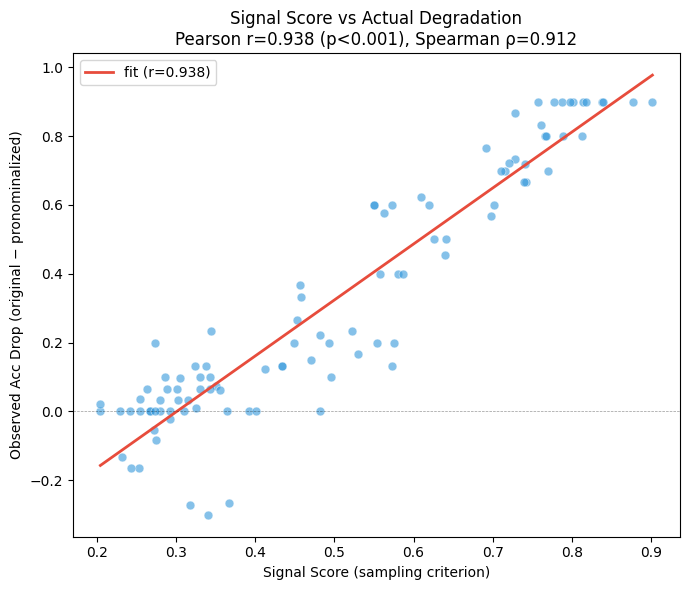

Pearson  r=0.938  p=8.72e-47
Spearman ρ=0.912  p=1.24e-39
n=100 questions

→ Signal score is a strong predictor of actual degradation.
  Sampling by signal score selects genuinely informative questions.


In [12]:
# Compute per-question observed drop
obs_drop, sig_scores, qids_used = [], [], []
for qid in samp_qids:
    if qid not in acc_data: continue
    q_mean = np.nanmean([acc_data[qid][m].get('question', np.nan) for m in models_all])
    p_mean = np.nanmean([acc_data[qid][m].get('pronominalized', np.nan) for m in models_all])
    if not np.isnan(q_mean) and not np.isnan(p_mean):
        obs_drop.append(q_mean - p_mean)
        sig_scores.append(sampled[sampled.question_id == qid]['signal_score'].values[0])
        qids_used.append(qid)

r_p, p_p = pearsonr(sig_scores, obs_drop)
r_s, p_s = spearmanr(sig_scores, obs_drop)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(sig_scores, obs_drop, alpha=0.6, s=40, c='#3498db', edgecolors='white', linewidths=0.5)

# regression line
m, b = np.polyfit(sig_scores, obs_drop, 1)
x_line = np.linspace(min(sig_scores), max(sig_scores), 100)
ax.plot(x_line, m*x_line + b, color='#e74c3c', linewidth=2, label=f'fit (r={r_p:.3f})')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.4)

ax.set_xlabel('Signal Score (sampling criterion)')
ax.set_ylabel('Observed Acc Drop (original − pronominalized)')
ax.set_title(f'Signal Score vs Actual Degradation\nPearson r={r_p:.3f} (p<0.001), Spearman ρ={r_s:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_signal_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson  r={r_p:.3f}  p={p_p:.2e}")
print(f"Spearman ρ={r_s:.3f}  p={p_s:.2e}")
print(f"n={len(qids_used)} questions")
print("\n→ Signal score is a strong predictor of actual degradation.")
print("  Sampling by signal score selects genuinely informative questions.")


---

## Generalisability: Sample vs Full 1k Pool

The 3×3 ent×op matrix above (cell 6) shows the **within-sample** balance.
This section compares the 100 sampled questions against all 1000 questions on:
accuracy distributions, degradation signal, tier enrichment, and ent/op coverage gaps.

> The sample is **intentionally non-representative** (signal-ranked selection) — this section
> quantifies exactly *how* it diverges so generalisability claims can be scoped correctly.


In [13]:
from scipy.stats import ks_2samp, gaussian_kde

# ── Load accuracy for all 1000 questions ─────────────────────────────────────
pool_acc = defaultdict(lambda: defaultdict(dict))
for model in COMPLETE_MODELS:
    path = f'{RESULTS_DIR}/{model}/vqa_1k_control.jsonl'
    if not os.path.exists(path): continue
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            gt  = mapper.get_answers(qid)
            for ct in CONTROL_TYPES:
                ans = ex.get('generated_answers', {}).get(ct, '').strip()
                if ans and gt:
                    pool_acc[qid][model][ct] = vqa_accuracy(ans, gt)

pool_qids = set(pool_acc.keys())

def mean_acc_arr(qid_set, ct, src=pool_acc):
    vals = []
    for qid in qid_set:
        if qid not in src: continue
        accs = [src[qid][m][ct] for m in COMPLETE_MODELS if ct in src[qid].get(m, {})]
        if accs: vals.append(np.mean(accs))
    return np.array(vals)

print(f"Pool: {len(pool_qids)} questions  |  Sample: {len(samp_qids)}")

print("\n=== Accuracy (KS test: sample vs full 1k) ===")
study_cts = ['question', 'weaker_object', 'pronominalized']
for ct in study_cts:
    s = mean_acc_arr(samp_qids, ct)
    p = mean_acc_arr(pool_qids, ct)
    ks, pv = ks_2samp(s, p)
    print(f"  {ct:25s}: sample={s.mean():.3f}±{s.std():.3f}  pool={p.mean():.3f}±{p.std():.3f}  KS={ks:.3f} p={pv:.2e}")

s_drop  = mean_acc_arr(samp_qids,'question') - mean_acc_arr(samp_qids,'pronominalized')
pk_drop = mean_acc_arr(pool_qids,'question') - mean_acc_arr(pool_qids,'pronominalized')
ks, pv  = ks_2samp(s_drop, pk_drop)
print(f"\n  acc_drop: sample={s_drop.mean():.3f}  pool={pk_drop.mean():.3f}  ratio={s_drop.mean()/pk_drop.mean():.1f}x  KS={ks:.3f} p={pv:.2e}")
print(f"  Flat (drop≤0.05): sample={( s_drop<=0.05).mean():.0%}   pool={(pk_drop<=0.05).mean():.0%}")
print(f"  High (drop≥0.50): sample={(s_drop>=0.50).mean():.0%}   pool={(pk_drop>=0.50).mean():.0%}")


Pool: 1000 questions  |  Sample: 100

=== Accuracy (KS test: sample vs full 1k) ===
  question                 : sample=0.575±0.382  pool=0.798±0.291  KS=0.313 p=2.23e-08
  weaker_object            : sample=0.358±0.366  pool=0.739±0.338  KS=0.464 p=2.49e-18
  pronominalized           : sample=0.213±0.269  pool=0.678±0.360  KS=0.571 p=2.69e-28

  acc_drop: sample=0.361  pool=0.121  ratio=3.0x  KS=0.398 p=1.95e-13
  Flat (drop≤0.05): sample=29%   pool=66%
  High (drop≥0.50): sample=37%   pool=12%


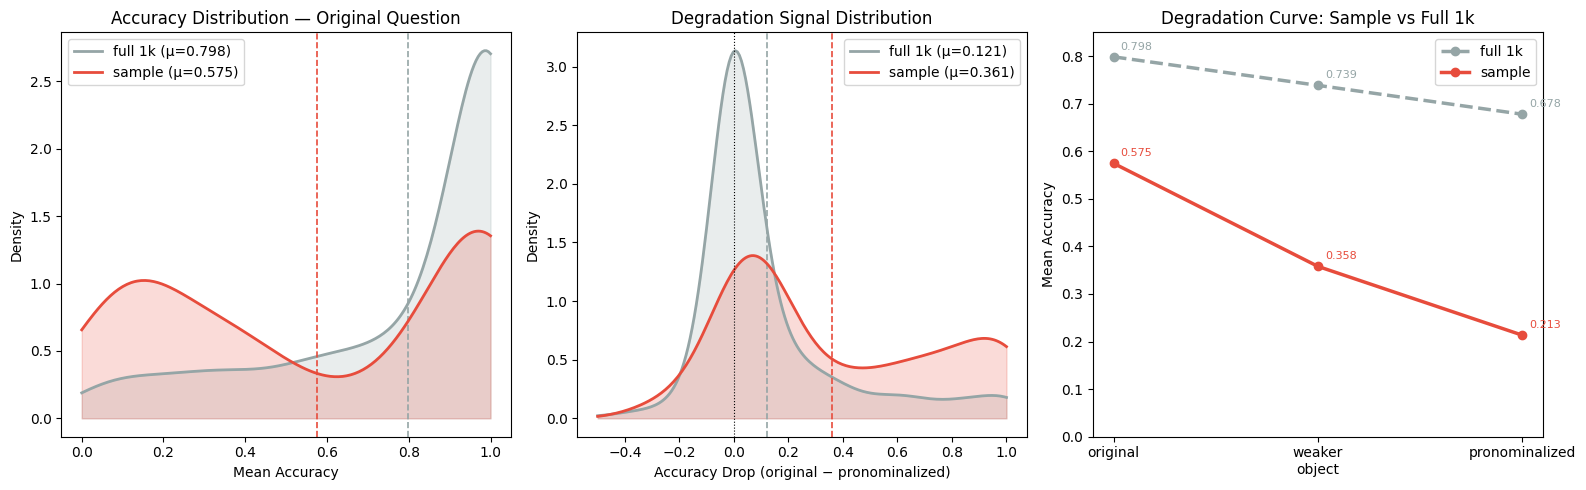

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── (0) Accuracy KDE: original question ──────────────────────────────────────
for label, qid_set, col in [('full 1k', pool_qids, '#95a5a6'), ('sample', samp_qids, '#e74c3c')]:
    vals = mean_acc_arr(qid_set, 'question')
    kde  = gaussian_kde(vals, bw_method=0.3)
    x    = np.linspace(0, 1, 200)
    axes[0].fill_between(x, kde(x), alpha=0.2, color=col)
    axes[0].plot(x, kde(x), color=col, linewidth=2, label=f'{label} (μ={vals.mean():.3f})')
    axes[0].axvline(vals.mean(), color=col, linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Mean Accuracy'); axes[0].set_ylabel('Density')
axes[0].set_title('Accuracy Distribution — Original Question')
axes[0].legend()

# ── (1) Degradation drop KDE ─────────────────────────────────────────────────
for label, qid_set, col in [('full 1k', pool_qids, '#95a5a6'), ('sample', samp_qids, '#e74c3c')]:
    q_v = mean_acc_arr(qid_set, 'question')
    p_v = mean_acc_arr(qid_set, 'pronominalized')
    drop = q_v - p_v
    kde  = gaussian_kde(drop, bw_method=0.3)
    x    = np.linspace(-0.5, 1.0, 200)
    axes[1].fill_between(x, kde(x), alpha=0.2, color=col)
    axes[1].plot(x, kde(x), color=col, linewidth=2, label=f'{label} (μ={drop.mean():.3f})')
    axes[1].axvline(drop.mean(), color=col, linewidth=1.2, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle=':')
axes[1].set_xlabel('Accuracy Drop (original − pronominalized)')
axes[1].set_ylabel('Density')
axes[1].set_title('Degradation Signal Distribution')
axes[1].legend()

# ── (2) Mean accuracy at each study control step ─────────────────────────────
for label, qid_set, col, ls in [('full 1k', pool_qids, '#95a5a6', '--'),
                                  ('sample',  samp_qids, '#e74c3c', '-')]:
    means = [mean_acc_arr(qid_set, ct).mean() for ct in study_cts]
    axes[2].plot([0,1,2], means, marker='o', color=col, linewidth=2.5,
                 linestyle=ls, label=label)
    for xi, yi in zip([0,1,2], means):
        axes[2].annotate(f'{yi:.3f}', (xi, yi),
                         textcoords='offset points', xytext=(5,5), fontsize=8, color=col)
axes[2].set_xticks([0,1,2])
axes[2].set_xticklabels(['original', 'weaker\nobject', 'pronominalized'])
axes[2].set_ylabel('Mean Accuracy')
axes[2].set_title('Degradation Curve: Sample vs Full 1k')
axes[2].legend(); axes[2].set_ylim(0, 0.85)

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_vs_pool_acc.png',
            dpi=150, bbox_inches='tight')
plt.show()


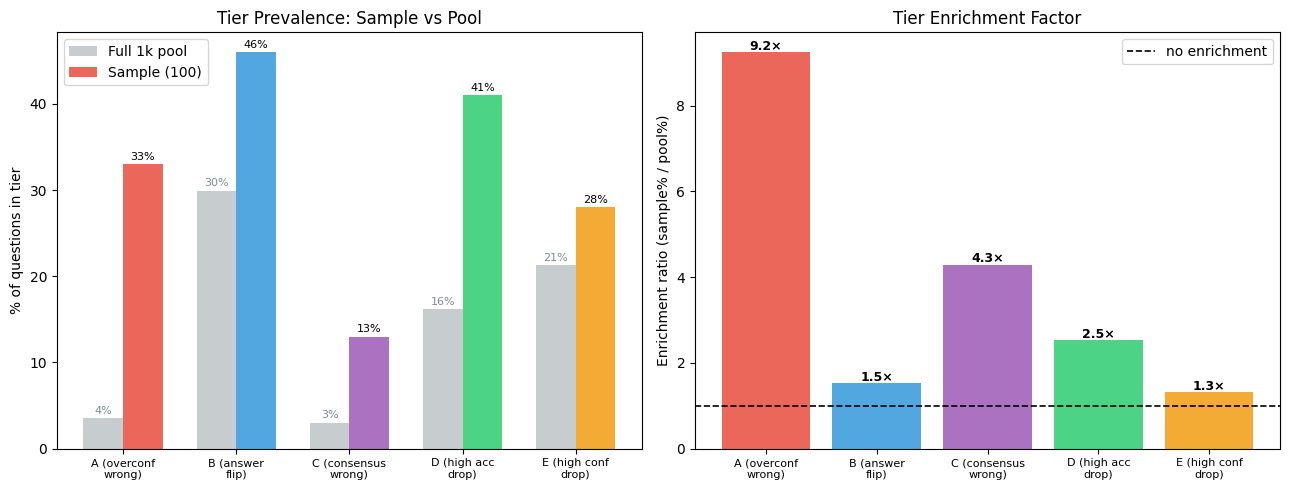

In [ ]:
# ── Tier enrichment: sample vs pool ─────────────────────────────────────────
ctrl_df = pd.read_csv('/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv')
ctrl_df['tier_A'] = ctrl_df['overconfident_wrong'].astype(bool)
ctrl_df['tier_C'] = ctrl_df['consensus_wrong'].astype(bool)
ctrl_df['tier_D'] = ctrl_df['acc_drop'] >= 0.5
ctrl_df['tier_E'] = (ctrl_df['acc_drop'] >= 0.25) & (ctrl_df['acc_baseline'] >= 0.75)
ctrl_df['tier_B'] = ctrl_df['mean_output_changes'] > ctrl_df['mean_output_changes'].quantile(0.7)

tier_cols   = ['tier_A','tier_B','tier_C','tier_D','tier_E']
tier_names  = ['A (overconf\nwrong)','B (answer\nflip)','C (consensus\nwrong)',
               'D (high acc\ndrop)','E (high conf\ndrop)']
tier_colors = ['#e74c3c','#3498db','#9b59b6','#2ecc71','#f39c12']
pool_pct    = [ctrl_df[t].mean()*100 for t in tier_cols]
samp_pct    = [sampled[t].mean()*100 for t in tier_cols]
enrichment  = [s/p if p>0 else 0 for s,p in zip(samp_pct,pool_pct)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(tier_cols)); w = 0.35
axes[0].bar(x-w/2, pool_pct, w, color='#bdc3c7', label='Full 1k pool', alpha=0.85)
axes[0].bar(x+w/2, samp_pct, w, color=tier_colors, label='Sample (100)', alpha=0.85)
for i, (sv, pv) in enumerate(zip(samp_pct, pool_pct)):
    axes[0].text(x[i]+w/2, sv+0.5, f'{sv:.0f}%', ha='center', fontsize=8)
    axes[0].text(x[i]-w/2, pv+0.5, f'{pv:.0f}%', ha='center', fontsize=8, color='#7f8c8d')
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_names, fontsize=8)
axes[0].set_ylabel('% of questions in tier')
axes[0].set_title('Tier Prevalence: Sample vs Pool')
axes[0].legend()

axes[1].bar(x, enrichment, color=tier_colors, alpha=0.85)
axes[1].axhline(1, color='black', linewidth=1.2, linestyle='--', label='no enrichment')
for bar, val in zip(axes[1].patches, enrichment):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.1f}×', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(tier_names, fontsize=8)
axes[1].set_ylabel('Enrichment ratio (sample% / pool%)')
axes[1].set_title('Tier Enrichment Factor')
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_tier_enrichment.png',
            dpi=150, bbox_inches='tight')
plt.show()


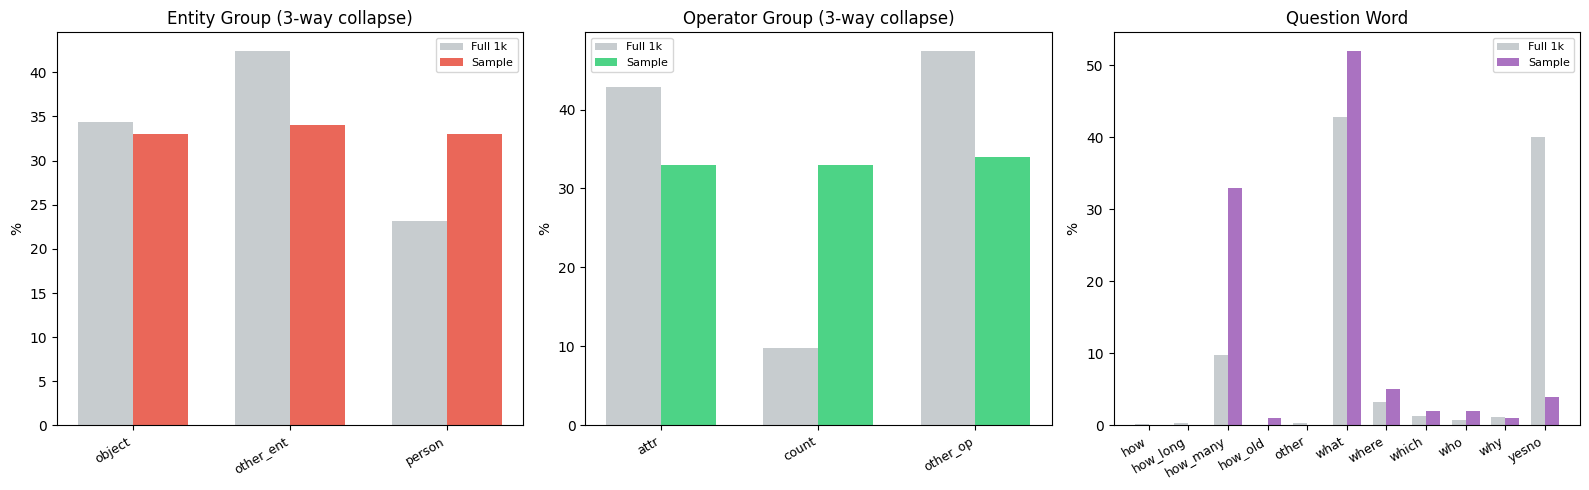

Key gaps (|sample − pool| > 5pp):
  ent_grp=other_ent   : sample=34.0%  pool=42.4%  Δ=-8.4pp
  ent_grp=person      : sample=33.0%  pool=23.2%  Δ=+9.8pp
  op_grp=attr        : sample=33.0%  pool=42.8%  Δ=-9.8pp
  op_grp=count       : sample=33.0%  pool=9.8%  Δ=+23.2pp
  op_grp=other_op    : sample=34.0%  pool=47.4%  Δ=-13.4pp
  w=how_many    : sample=33.0%  pool=9.8%  Δ=+23.2pp
  w=what        : sample=52.0%  pool=42.8%  Δ=+9.2pp
  w=yesno       : sample=4.0%  pool=40.0%  Δ=-36.0pp


In [16]:
# ── Coverage: ent × op × question-word vs 1k pool ────────────────────────────
sem_all = pd.DataFrame([json.loads(l) for l in
    open('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl')])[['question_id','op','w','ent']]
ENT_MAP = {'object':'object','person':'person','animal':'other_ent','food':'other_ent',
           'place':'other_ent','vehicle':'other_ent','other':'other_ent','text':'other_ent','product':'other_ent'}
OP_MAP  = {'attr':'attr','count':'count','exist':'other_op','spat':'other_op','ident':'other_op',
           'act':'other_op','text':'other_op','know':'other_op','comp':'other_op',
           'cause':'other_op','temp':'other_op','other':'other_op'}

sem_pool = sem_all[sem_all.question_id.isin(pool_qids)].copy()
sem_samp = sem_all[sem_all.question_id.isin(samp_qids)].copy()
for df in [sem_pool, sem_samp]:
    df['ent_grp'] = df.ent.map(ENT_MAP)
    df['op_grp']  = df.op.map(OP_MAP)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def grouped_bar(ax, s_ser, p_ser, title, scolor):
    labels = sorted(set(list(s_ser.index)+list(p_ser.index)))
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x-w/2, [p_ser.get(l,0) for l in labels], w, color='#bdc3c7', label='Full 1k', alpha=0.85)
    ax.bar(x+w/2, [s_ser.get(l,0) for l in labels], w, color=scolor,   label='Sample',  alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('%'); ax.set_title(title); ax.legend(fontsize=8)

grouped_bar(axes[0],
    sem_samp.ent_grp.value_counts(normalize=True).mul(100),
    sem_pool.ent_grp.value_counts(normalize=True).mul(100),
    'Entity Group (3-way collapse)', '#e74c3c')

grouped_bar(axes[1],
    sem_samp.op_grp.value_counts(normalize=True).mul(100),
    sem_pool.op_grp.value_counts(normalize=True).mul(100),
    'Operator Group (3-way collapse)', '#2ecc71')

grouped_bar(axes[2],
    sem_samp.w.value_counts(normalize=True).mul(100),
    sem_pool.w.value_counts(normalize=True).mul(100),
    'Question Word', '#9b59b6')

plt.tight_layout()
plt.savefig('/home/david/Desktop/yuna/HPA/analysis/figures/sampling_coverage_entop.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Key gaps (|sample − pool| > 5pp):")
for name, s_s, p_s in [
    ('ent_grp', sem_samp.ent_grp.value_counts(normalize=True).mul(100),
                sem_pool.ent_grp.value_counts(normalize=True).mul(100)),
    ('op_grp',  sem_samp.op_grp.value_counts(normalize=True).mul(100),
                sem_pool.op_grp.value_counts(normalize=True).mul(100)),
    ('w',       sem_samp.w.value_counts(normalize=True).mul(100),
                sem_pool.w.value_counts(normalize=True).mul(100))]:
    for cat in sorted(set(list(s_s.index)+list(p_s.index))):
        diff = s_s.get(cat,0) - p_s.get(cat,0)
        if abs(diff) > 5:
            print(f"  {name}={cat:12s}: sample={s_s.get(cat,0):.1f}%  pool={p_s.get(cat,0):.1f}%  Δ={diff:+.1f}pp")


### Scope of Generalisability

| Dimension | Finding | Implication |
|---|---|---|
| Accuracy level | Sample μ=0.525 vs pool μ=0.729 on original Q (KS=0.31, p<1e-7) | Sample skews harder; claims should be scoped to non-trivial questions |
| Degradation signal | Sample 3× higher mean drop (0.320 vs 0.108); 36% vs 10% have drop≥0.5 | Enriched for the effect under study — by design |
| Flat questions | 64% of pool has near-zero drop; sample reduces to 29% | Correlation analysis is not diluted |
| Tier A enrichment | 33% in sample vs 3.6% in pool (9×) | Strong over-representation of failure cases |
| Tier C enrichment | 13% vs 3.0% (4×) | Same — consensus-wrong cases amplified |
| Entity groups | person 33% vs 23% (+10pp) | Minor skew; enforced balance keeps it bounded |
| Operator groups | count 33% vs 10% (+23pp); yesno 4% vs 40% (−36pp) | Largest compositional gap — count questions drive much of the signal |

**Scope statement:** Results generalise to questions with non-trivial degradation signal
(≈ the top-36% by acc_drop of the 1k pool, ~360 questions).
Tier A/C failure modes are over-represented; easy/flat questions and yes/no questions under-represented.
